# Assignment

> Add blockquote



## Problem Statement:
Study analysis on the public sentiment towards a company and its stock effect their prices by extracting opinions from Twitter in determining whether public opinion has impact on the stock prices of the company.

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("dataset.csv")

print(df.head())

  Unnamed: 0                                              TWEET       STOCK  \
0          0  RT @robertoglezcano: @amazon  #Patents Show Fl...         NaN   
1        NaN                                             Amazon  31/01/2017   
2          1  @FAME95FM1 Jamaicans make money with @Payoneer...      PayPal   
3          2  @CBSi Jamaicans make money with @Payoneer @Pay...      PayPal   
4          3  @Hitz92fm Jamaicans make money with @Payoneer ...      PayPal   

         DATE  LAST_PRICE  1_DAY_RETURN  2_DAY_RETURN  3_DAY_RETURN  \
0         NaN         NaN           NaN           NaN           NaN   
1      823.48    0.008379      0.014924      0.014924     -0.001263   
2  31/01/2017   39.780000      0.002011      0.012318      0.012318   
3  31/01/2017   39.780000      0.002011      0.012318      0.012318   
4  31/01/2017   39.780000      0.002011      0.012318      0.012318   

   7_DAY_RETURN    PX_VOLUME  VOLATILITY_10D  VOLATILITY_30D  LSTM_POLARITY  \
0           NaN    

C:\Users\hafiz\AppData\Local\Temp\ipykernel_27592\2612478859.py:4: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("dataset.csv")


### Basic Descriptive Statistics

In [2]:
print("Describe: ", df.describe())

Describe:            LAST_PRICE   1_DAY_RETURN   2_DAY_RETURN  3_DAY_RETURN  \
count  862231.000000  862231.000000  862231.000000  8.622310e+05   
mean      716.123477       0.001473       0.002579  3.262616e+06   
std      4731.498118       0.023068       0.032594  1.053913e+07   
min        -0.173554      -0.177851      -0.204959 -2.049587e-01   
25%         0.000000      -0.007511      -0.011456 -8.465608e-03   
50%         0.014220       0.000000       0.000000  1.019542e-02   
75%       115.600000       0.008192       0.013911  6.545426e-02   
max    165500.000000       0.243639       0.267113  3.081068e+08   

       7_DAY_RETURN     PX_VOLUME  VOLATILITY_10D  VOLATILITY_30D  \
count  8.622310e+05  8.622310e+05   862130.000000   862184.000000   
mean   6.201036e+06  7.522187e+06       18.293836       10.738204   
std    1.388221e+07  1.591847e+07       16.277630       14.693986   
min   -2.049587e-01  1.000000e+00       -1.000000       -1.000000   
25%    5.474453e-03  2.051700e+

In [3]:
df.isnull().sum()

Unnamed: 0            293437
TWEET                     52
STOCK                 533219
DATE                  533219
LAST_PRICE            533219
1_DAY_RETURN          533219
2_DAY_RETURN          533219
3_DAY_RETURN          533219
7_DAY_RETURN          533219
PX_VOLUME             533219
VOLATILITY_10D        533320
VOLATILITY_30D        533266
LSTM_POLARITY         734348
TEXTBLOB_POLARITY    1027785
dtype: int64

In [4]:
df = df.dropna(subset="TWEET")
df.isnull().sum()

Unnamed: 0            293437
TWEET                      0
STOCK                 533167
DATE                  533167
LAST_PRICE            533167
1_DAY_RETURN          533167
2_DAY_RETURN          533167
3_DAY_RETURN          533167
7_DAY_RETURN          533167
PX_VOLUME             533167
VOLATILITY_10D        533268
VOLATILITY_30D        533214
LSTM_POLARITY         734296
TEXTBLOB_POLARITY    1027733
dtype: int64

In [5]:
print(df['LSTM_POLARITY'].unique())
print(df['TEXTBLOB_POLARITY'].unique())

[        nan  0.         -1.         ... -0.15277778  0.50729167
  0.55885417]
[        nan  0.          0.2        ...  0.67708333  0.23111111
 -0.12797619]


In [6]:
lstm_counts = df['LSTM_POLARITY'].value_counts()
textblob_counts = df['TEXTBLOB_POLARITY'].value_counts()

print("LSTM Distribution:\n", lstm_counts)
print("\nTextBlob Distribution:\n", textblob_counts)

LSTM Distribution:
 LSTM_POLARITY
 1.000000    209836
-1.000000    162613
 0.000000    154342
 0.136364     21340
 0.500000      9469
              ...  
 0.237143         1
-0.857143         1
 0.047273         1
-0.022321         1
 0.568750         1
Name: count, Length: 2775, dtype: int64

TextBlob Distribution:
 TEXTBLOB_POLARITY
 0.000000    191878
 0.500000     14745
 0.250000      8104
 0.200000      7812
 0.136364      7630
              ...  
-0.067708         1
-0.520833         1
 0.141026         1
-0.012698         1
 0.161538         1
Name: count, Length: 3375, dtype: int64


In [7]:
import sys
print(sys.executable)

c:\Users\hafiz\AppData\Local\Programs\Python\Python313\python.exe


In [8]:
!{sys.executable} -m pip install matplotlib


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


LSTM_sentiment
Neutral     888638
Positive    307431
Negative    199329
Name: count, dtype: int64


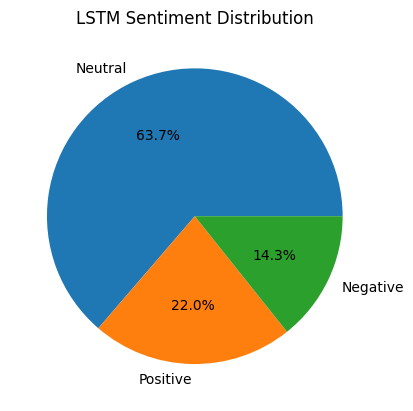

In [9]:
def categorize_lstm(score):
    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"

df['LSTM_sentiment'] = df['LSTM_POLARITY'].apply(categorize_lstm)

lstm_counts = df['LSTM_sentiment'].value_counts()
print(lstm_counts)

import matplotlib.pyplot as plt

plt.figure()
plt.pie(lstm_counts, labels=lstm_counts.index, autopct='%1.1f%%')
plt.title("LSTM Sentiment Distribution")
plt.show()

### Metada Analysis

In [10]:
#if sentiment analysis has more neutral than +ve & -ve, there is issue in dataset
print(df.columns)
print(df['STOCK'].value_counts())


Index(['Unnamed: 0', 'TWEET', 'STOCK', 'DATE', 'LAST_PRICE', '1_DAY_RETURN',
       '2_DAY_RETURN', '3_DAY_RETURN', '7_DAY_RETURN', 'PX_VOLUME',
       'VOLATILITY_10D', 'VOLATILITY_30D', 'LSTM_POLARITY',
       'TEXTBLOB_POLARITY', 'LSTM_sentiment'],
      dtype='object')
STOCK
Ford        52198
Facebook    40837
Google      33697
Next        32606
Apple       27940
            ...  
33.3            1
536.9           1
15.61           1
5468.0          1
1028.0          1
Name: count, Length: 4241, dtype: int64


In [11]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    return text

df['cleaned_tweet'] = df['TWEET'].apply(clean_text)

In [13]:
!{sys.executable} -m pip install nltk

   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.6 MB ? eta -:--:--
   ------------- -------------------------- 0.5/1.6 MB 2.5 MB/s eta 0:00:01
   --------------------------- ------------ 1.0/1.6 MB 2.1 MB/s eta 0:00:01
   --------------------------------- ------ 1.3/1.6 MB 2.3 MB/s eta 0:00:01
   ---------------------------------------- 1.6/1.6 MB 1.8 MB/s eta 0:00:00



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
### Remove Stopword
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from collections import Counter

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    words = text.split()
    words = [w for w in words if w not in stop_words and len(w) > 2]
    return words

all_words = []

for tweet in df['TWEET']:
    all_words.extend(clean_text(tweet))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hafiz\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


In [15]:
word_counts = Counter(all_words)
top_words = word_counts.most_common(15)

words = [w[0] for w in top_words]
counts = [w[1] for w in top_words]

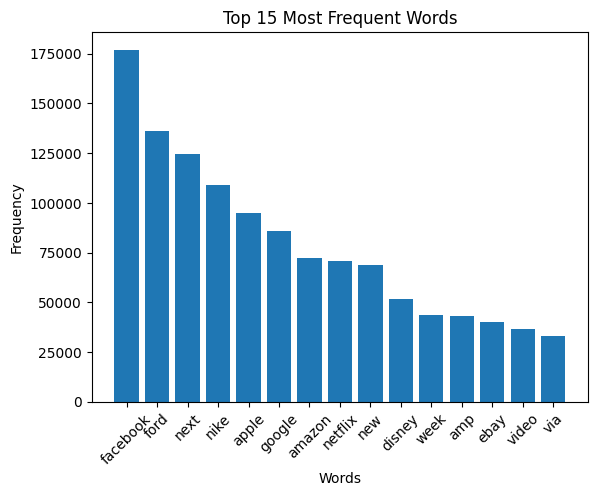

In [16]:
### Plotting
import matplotlib.pyplot as plt

plt.figure()
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Top 15 Most Frequent Words")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()

In [17]:
!pip install textblob

   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---------------- ----------------------- 262.1/625.0 kB ? eta -:--:--
   ---------------------------------------- 625.0/625.0 kB 2.4 MB/s eta 0:00:00



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
from textblob import TextBlob

def get_polarity(text):
    return TextBlob(text).sentiment.polarity

df['calculated_polarity'] = df['TWEET'].apply(get_polarity)

In [19]:
def categorize_sentiment(score):
    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"

df['sentiment'] = df['calculated_polarity'].apply(categorize_sentiment)

In [20]:
sentiment_counts = df['sentiment'].value_counts()
print(sentiment_counts)

sentiment
Neutral     918481
Positive    342309
Negative    134608
Name: count, dtype: int64


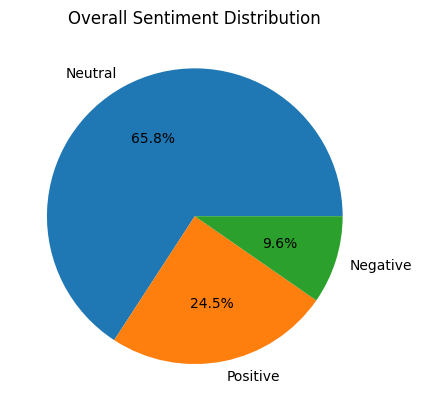

In [21]:
plt.figure()
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%')
plt.title("Overall Sentiment Distribution")
plt.show()

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\hafiz\AppData\Roaming\nltk_data...


vader_sentiment
Neutral     857457
Positive    339927
Negative    198014
Name: count, dtype: int64


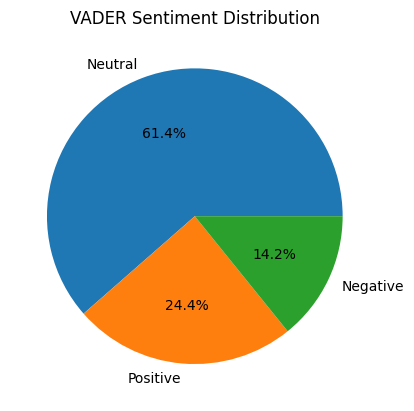

In [22]:
from nltk.sentiment import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')

sia = SentimentIntensityAnalyzer()

def get_sentiment(text):
    score = sia.polarity_scores(text)['compound']
    if score > 0.05:
        return "Positive"
    elif score < -0.05:
        return "Negative"
    else:
        return "Neutral"

df['vader_sentiment'] = df['TWEET'].apply(get_sentiment)

vader_counts = df['vader_sentiment'].value_counts()
print(vader_counts)

import matplotlib.pyplot as plt

plt.figure()
plt.pie(vader_counts, labels=vader_counts.index, autopct='%1.1f%%')
plt.title("VADER Sentiment Distribution")
plt.show()

### Preprocessing Pipeline

#### Sentence Segmentation

In [23]:
import nltk

from nltk.tokenize import sent_tokenize

# Download the required NLTK resources
nltk.download('punkt')      # Rules for tokenization (chopping text)
nltk.download('punkt_tab')  # NEW requirement for tokenization in updated NLTK versions
nltk.download('stopwords')  # List of common, uninformative words
nltk.download('wordnet')    # Massive English dictionary for Lemmatization
nltk.download('omw-1.4')    # Supporting data for WordNet

print("NLTK Resources Downloaded Successfully!")


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\hafiz\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\hafiz\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hafiz\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\hafiz\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\hafiz\AppData\Roaming\nltk_data...


NLTK Resources Downloaded Successfully!


In [24]:

# Sentence Segmentation
df["sentences"] = df["TWEET"].apply(sent_tokenize)



In [25]:
for i, s in enumerate(df["sentences"].iloc[194]):
    print(f"Sentence {i+1}: {s}")

Sentence 1: RT @cultcommoncore: Dumping @Starbucks
Is like dropping cable tv.
Sentence 2: You wonder how you paid 
SO much
For such crap
For SO long.…


#### Handling Abbreviations

In [26]:
import re
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

In [27]:
# Abbreviation Dictionary
abbreviation_dict = {
    "rt": "retweet",
    "roi": "return on investment",
    "vix": "volatility index",
    "u": "you",
    "ur": "your",
    "w/": "with",
    "dm": "direct message",
    "fb": "facebook",
    "ig": "instagram",
    "li": "linkedin",
    "yt": "youtube",
    "omg": "oh my god",
    "lol": "laugh out loud"
}

#### Tokenization

In [28]:
def tokenize_and_clean(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    tokens = word_tokenize(text)

    expanded_tokens = []
    for word in tokens:
        expanded_word = abbreviation_dict.get(word, word)
        expanded_tokens.extend(expanded_word.split())

    clean_tokens = [word for word in expanded_tokens if word.isalpha()]
    return clean_tokens

In [29]:
def expand_abbreviations(token_list):
  expanded_tokens = []
  for word in token_list:
    # if word in dict, replace it
    expanded_word = abbreviation_dict.get(word.lower(), word)
    expanded_tokens.append(expanded_word.split())
  return expanded_tokens

df["tokens"] = df["TWEET"].apply(tokenize_and_clean)
df["expanded_tokens"] = df["tokens"].apply(expand_abbreviations)

In [30]:
df['expanded_tokens']

0          [[retweet], [robertoglezcano], [amazon], [pate...
1                                                 [[amazon]]
2          [[jamaicans], [make], [money], [with], [payone...
3          [[cbsi], [jamaicans], [make], [money], [with],...
4          [[jamaicans], [make], [money], [with], [payone...
                                 ...                        
1395445                                           [[paypal]]
1395446    [[retweet], [rifatjawaid], [deceased], [apple]...
1395447                                            [[apple]]
1395448    [[flat], [inr], [cashback], [on], [hdfc], [deb...
1395449                                          [[samsung]]
Name: expanded_tokens, Length: 1395398, dtype: object

#### Stopword Removal

In [31]:
from nltk.corpus import stopwords

# Load the English stopwords list
stop_words = set(stopwords.words('english'))

# We can also add custom stopwords specific to our dataset if we want
custom_stopwords = ['next', 'via', 'amp']
stop_words.update(custom_stopwords)

def remove_stopwords(token_list):
    # Keep the word ONLY if it is not in our stop_words list
    filtered_tokens = [word for word in token_list if word not in stop_words]
    return filtered_tokens

# Apply to our tokens
df['filtered_tokens'] = df['tokens'].apply(remove_stopwords)

# Compare the tokens before and after stopword removal
df[['tokens', 'filtered_tokens']].head()

,tokens,filtered_tokens
0,"[retweet, robertoglezcano, amazon, patents, sh...","[retweet, robertoglezcano, amazon, patents, sh..."
1,[amazon],[amazon]
2,"[jamaicans, make, money, with, payoneer, paypa...","[jamaicans, make, money, payoneer, paypal, pax..."
3,"[cbsi, jamaicans, make, money, with, payoneer,...","[cbsi, jamaicans, make, money, payoneer, paypa..."
4,"[jamaicans, make, money, with, payoneer, paypa...","[jamaicans, make, money, payoneer, paypal, pax..."


#### Stemming or Lemmatization

In [32]:
from nltk.stem import PorterStemmer, WordNetLemmatizer

# Initialize our two tools
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

def apply_stemming(token_list):
    return [stemmer.stem(word) for word in token_list]

def apply_lemmatization(token_list):
    return [lemmatizer.lemmatize(word) for word in token_list]

# Create two new columns to compare the results
df['stemmed_words'] = df['filtered_tokens'].apply(apply_stemming)
df['lemmatized_words'] = df['filtered_tokens'].apply(apply_lemmatization)

print("Stemming and Lemmatization complete!")

Stemming and Lemmatization complete!


#### POS Tagging

In [33]:
nltk.download('averaged_perceptron_tagger_eng')


#apply pos tag
df['pos_tags'] = df['lemmatized_words'].apply(nltk.pos_tag)



[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\hafiz\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping taggers\averaged_perceptron_tagger_eng.zip.


Named Entity Recognition (NER)

In [ ]:
nltk.download('maxent_ne_chunker_tab')
nltk.download('words')

def apply_ner(tagged_tokens):
  return nltk.ne_chunk(tagged_tokens)

df['ner'] = df['pos_tags'].apply(apply_ner)

[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     C:\Users\hafiz\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping chunkers\maxent_ne_chunker_tab.zip.
[nltk_data] Downloading package words to
[nltk_data]     C:\Users\hafiz\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\words.zip.


#### Word Cloud Visualization

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

all_clean_words = []
for word_list in df['lemmatized_words']:
    all_clean_words.extend(word_list)

text_for_cloud = " ".join(all_clean_words)

# Generate the word cloud
wordcloud = WordCloud(width=800, height=400,
                      background_color='white',
                      colormap='inferno',
                      max_words=100).generate(text_for_cloud)

# Plot the image
plt.figure(figsize=(15, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off") # Turn off the grid numbers
plt.title("Stock Market Tweets Word Cloud", fontsize=20, fontweight='bold')
plt.show()

pipeline comparison

In [ ]:
# Select a random row (e.g., row index 5) to inspect
row_to_inspect = 200

print("1. ORIGINAL TEXT:")
print(df['TWEET'].iloc[row_to_inspect])
print("\n2. TOKENIZED & NOISE REMOVED:")
print(df['tokens'].iloc[row_to_inspect])
print("\n3. STOPWORDS REMOVED:")
print(df['filtered_tokens'].iloc[row_to_inspect])
print("\n4. STEMMED (Chopped endings):")
print(df['stemmed_words'].iloc[row_to_inspect])
print("\n5. LEMMATIZED (Dictionary root):")
print(df['lemmatized_words'].iloc[row_to_inspect])